In [2]:
# --------------------------------------------------------------------
# UPDATED ENV SETUP FOR GOOGLE COLAB (2025)
# Only timm needs to be downgraded.
# Torch should stay at the default Colab version (2.9.0 + cu126)
# --------------------------------------------------------------------

!pip install timm==0.9.16
import torch, timm

print("Torch version:", torch.__version__)
print("timm version:", timm.__version__)


Torch version: 2.9.0+cu126
timm version: 0.9.16


In [3]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.amp.autocast_mode import autocast
from torch.cuda.amp import GradScaler
import torchvision.transforms as T
import torchvision.transforms.functional as TF
import numpy as np
import h5py, random
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc
import timm

device = "cuda" if torch.cuda.is_available() else "cpu"
device


'cuda'

In [4]:
from google.colab import drive
drive.mount('/content/drive')

TRAIN_H5 = "/content/drive/MyDrive/morph_project/processed/train.h5"
TEST_H5  = "/content/drive/MyDrive/morph_project/processed/test.h5"


Mounted at /content/drive


In [5]:
class H5Dataset(Dataset):
    def __init__(self, h5_path, train=False):
        self.h5 = h5py.File(h5_path, "r")
        self.X = self.h5["X"]
        self.y = self.h5["y"]
        self.train = train

        self.jitter = T.ColorJitter(
            brightness=0.10, contrast=0.10, saturation=0.10
        )

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        img = self.X[idx]
        label = int(self.y[idx])

        img_t = torch.from_numpy(img).permute(2,0,1).float()

        if self.train:
            if random.random() < 0.5:
                img_t = torch.flip(img_t, dims=[2])

            if random.random() < 0.15:
                angle = random.uniform(-5, 5)
                img_t = TF.rotate(img_t, angle)

            if random.random() < 0.15:
                img_t = self.jitter(img_t)

        return img_t, torch.tensor(label)


In [6]:
train_ds = H5Dataset(TRAIN_H5, train=True)
test_ds  = H5Dataset(TEST_H5,  train=False)

train_labels = np.array(train_ds.h5["y"][:])
class_counts = np.bincount(train_labels)

weights = 1.0 / class_counts
sample_weights = weights[train_labels]
sample_weights = torch.tensor(sample_weights, dtype=torch.double)

sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=16, sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)


In [7]:
model = timm.create_model("vit_base_patch16_224", pretrained=True, num_classes=2).to(device)

count_au, count_tp = class_counts
w0 = (count_au+count_tp) / (2*count_au)
w1 = (count_au+count_tp) / (2*count_tp)
class_w = torch.tensor([w0, w1]).float().to(device)

criterion = nn.CrossEntropyLoss(
    weight=class_w,
    label_smoothing=0.05     # ← NEW LABEL SMOOTHING
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-5,
    weight_decay=1e-5
)

EPOCHS = 22
total_steps = len(train_loader) * EPOCHS
warmup_steps = int(0.02 * total_steps)   # ← 2% warmup

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)

scaler = GradScaler()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

/tmp/ipython-input-1663156180.py:28: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [8]:
def mixup(x, y, alpha=0.1):
    if alpha <= 0:
        return x, y, 1.0
    lam = np.random.beta(alpha, alpha)
    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, (y_a, y_b), lam


In [9]:
history = {"train_loss":[], "train_acc":[], "val_loss":[], "val_acc":[]}
best_val_acc = 0
save_path = "/content/drive/MyDrive/morph_project/models/vit_advanced.pth"


def train_epoch():
    model.train()
    total, correct, loss_sum = 0, 0, 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        # Apply light Mixup
        imgs, mixed_labels, lam = mixup(imgs, labels, alpha=0.1)

        optimizer.zero_grad()

        with autocast("cuda"):
            outputs = model(imgs)

            y_a, y_b = mixed_labels
            loss = lam * criterion(outputs, y_a) + (1 - lam) * criterion(outputs, y_b)

        scaler.scale(loss).backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        scaler.step(optimizer)
        scaler.update()

        loss_sum += loss.item() * labels.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return loss_sum/total, correct/total


def evaluate():
    model.eval()
    total, correct, loss_sum = 0, 0, 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            with autocast("cuda"):
                outputs = model(imgs)
                loss = criterion(outputs, labels)

            loss_sum += loss.item() * labels.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return loss_sum/total, correct/total


In [10]:
for epoch in range(1, EPOCHS+1):
    tr_loss, tr_acc = train_epoch()
    val_loss, val_acc = evaluate()

    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch}/{EPOCHS}")
    print(f"Train Loss: {tr_loss:.4f} | Train Acc: {tr_acc*100:.2f}%")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc*100:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), save_path)
        print("🔥 Saved BEST Model:", best_val_acc*100)

print("\nTraining Finished!")


Epoch 1/22
Train Loss: 0.3858 | Train Acc: 58.31%
Val Loss:   0.7232 | Val Acc:   69.38%
🔥 Saved BEST Model: 69.38435940099833
Epoch 2/22
Train Loss: 0.2948 | Train Acc: 64.78%
Val Loss:   0.8727 | Val Acc:   63.84%
Epoch 3/22
Train Loss: 0.2613 | Train Acc: 68.25%
Val Loss:   0.8504 | Val Acc:   71.71%
🔥 Saved BEST Model: 71.71381031613977
Epoch 4/22
Train Loss: 0.2211 | Train Acc: 71.62%
Val Loss:   0.6773 | Val Acc:   82.97%
🔥 Saved BEST Model: 82.97282307265668
Epoch 5/22
Train Loss: 0.2168 | Train Acc: 74.38%
Val Loss:   0.8004 | Val Acc:   78.26%
Epoch 6/22
Train Loss: 0.2022 | Train Acc: 71.37%
Val Loss:   0.7911 | Val Acc:   78.09%
Epoch 7/22
Train Loss: 0.1942 | Train Acc: 73.58%
Val Loss:   0.7129 | Val Acc:   83.08%
🔥 Saved BEST Model: 83.08374930671104
Epoch 8/22
Train Loss: 0.1793 | Train Acc: 72.52%
Val Loss:   0.6770 | Val Acc:   85.14%
🔥 Saved BEST Model: 85.13588463671658
Epoch 9/22
Train Loss: 0.1719 | Train Acc: 73.50%
Val Loss:   0.7012 | Val Acc:   85.75%
🔥 Saved B

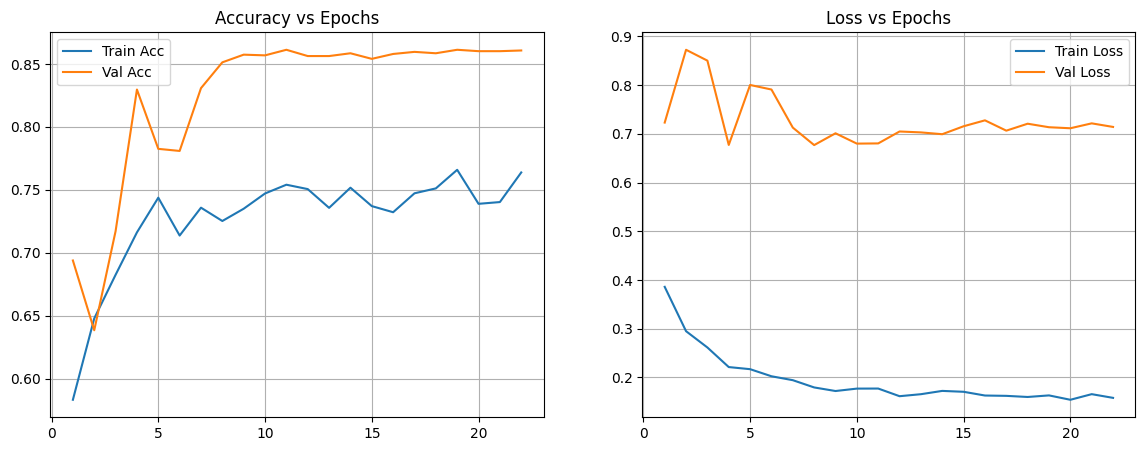

In [11]:
epochs = range(1, len(history["train_acc"])+1)

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(epochs, history["train_acc"], label="Train Acc")
plt.plot(epochs, history["val_acc"], label="Val Acc")
plt.title("Accuracy vs Epochs")
plt.grid(); plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.title("Loss vs Epochs")
plt.grid(); plt.legend()

plt.show()


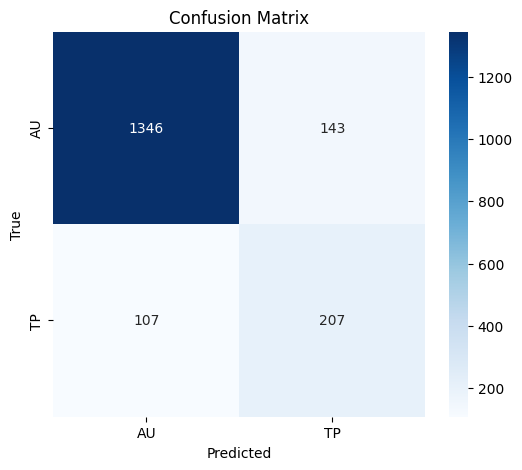

In [12]:
model.load_state_dict(torch.load(save_path))
model.eval()

y_true, y_pred = [], []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        out = model(imgs)
        y_pred.extend(out.argmax(1).cpu().numpy())
        y_true.extend(labels.numpy())

cm = confusion_matrix(y_true, y_pred)

import seaborn as sns
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["AU","TP"], yticklabels=["AU","TP"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()


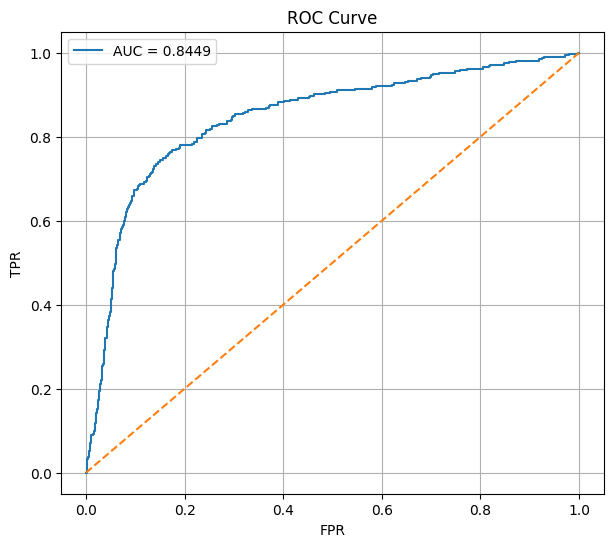

In [13]:
y_true, y_score = [], []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        probs = torch.softmax(model(imgs), dim=1)[:,1]
        y_score.extend(probs.cpu().numpy())
        y_true.extend(labels.numpy())

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.title("ROC Curve")
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.grid(); plt.legend()
plt.show()


In [14]:
# =======================================================
# PRECISION, RECALL, F1-SCORE (CLASSIFICATION REPORT)
# =======================================================

from sklearn.metrics import classification_report

model.load_state_dict(torch.load(save_path))
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(1)

        y_pred.extend(preds.cpu().numpy())
        y_true.extend(labels.numpy())

print("\n========== CLASSIFICATION REPORT ==========\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=["Authentic (0)", "Tampered (1)"],
    digits=4
))



========== CLASSIFICATION REPORT ==========

               precision    recall  f1-score   support

Authentic (0)     0.9264    0.9040    0.9150      1489
 Tampered (1)     0.5914    0.6592    0.6235       314

     accuracy                         0.8613      1803
    macro avg     0.7589    0.7816    0.7693      1803
 weighted avg     0.8680    0.8613    0.8643      1803



In [21]:
from google.colab import files
import cv2

MEAN = -2.6647588e-06
STD  = 0.9996273

def preprocess(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224,224))
    img = img.astype(np.float32)/255.0
    img = (img - MEAN) / (STD + 1e-7)
    img = torch.tensor(img).permute(2,0,1).float().unsqueeze(0)
    return img.to(device)

model.load_state_dict(torch.load(save_path))
model.eval()

def predict(path):
    img = preprocess(path)
    with torch.no_grad():
        out = model(img)
        probs = torch.softmax(out, dim=1)[0]

    cls = probs.argmax().item()
    conf = float(probs[cls] * 100)

    print("\n=======================")
    print("Image:", path)
    print("Prediction:", "Authentic (0)" if cls==0 else "Tampered (1)")
    print(f"Confidence: {conf:.2f}%")
    print("=======================\n")

uploaded = files.upload()
for name in uploaded:
    predict(name)


KeyboardInterrupt: 